# Point Like

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 13858
/bin/rm -f {acis,pcad}*.fits
download_chandra_obsid 13858
chandra_repro 13858 out="./" clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  553.6 kb/s
  oif      fits       23 Kb  ####################          < 1 s  1056.9 kb/s
  vv       pdf        35 Kb  ####################          < 1 s  1087.6 kb/s
  cntr_img fits       77 Kb  ####################          < 1 s  4425.5 kb/s
  cntr_img jpg       371 Kb  ####################          < 1 s  11198.7 kb/s
  evt2     fits        5 Mb  ####################          < 1 s  16815.3 kb/s
  full_img fits       52 Kb  ####################          < 1 s  5453.3 kb/s
  full_img jpg        42 Kb  ####################          < 1 s  4763.8 kb/s
  bpix     fits       11 Kb  ####################          < 1 s  1638.1 kb/s
  fov      fits        6 Kb  ####################          < 1 s  865.3 kb/s
  eph1     fits      308 Kb  ####################          < 1 

## Regions

In [3]:
cat << EOM > src.reg
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
fk5
circle(9:14:49.090,+8:53:21.231,4.083")
EOM

In [4]:
cat << EOM >  bkg.reg
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
fk5
annulus(9:14:49.074,+8:53:20.987,9.064",46.425") # background
EOM

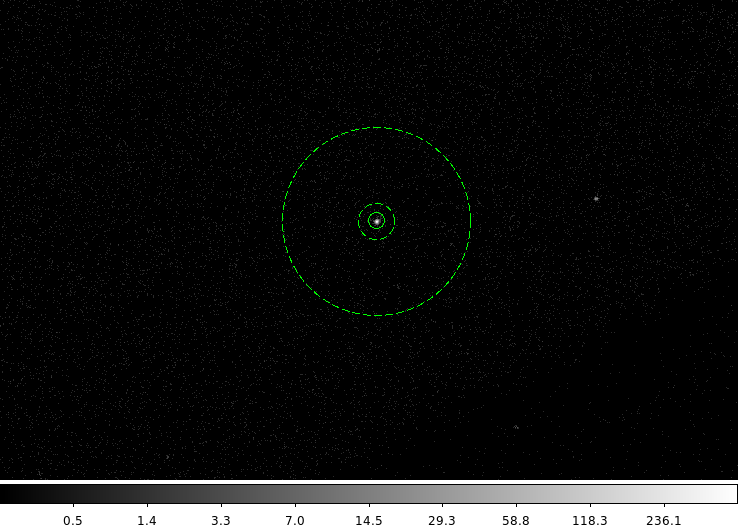

In [5]:
ds9 acisf13858_repro_evt2.fits -region src.reg -region bkg.reg \
  -scale log  -saveimage png ds9_01.png -quit

display < ds9_01.png

## Using specextract

In [6]:
pset specextract infile="acisf13858_repro_evt2.fits[sky=region(src.reg)]"
pset specextract bkgfile="acisf13858_repro_evt2.fits[sky=region(bkg.reg)]"
pset specextract outroot=SDSSJ091449.05+085321
pset specextract correctpsf=yes
pset specextract weight=no
specextract mode=h clob+


Running specextract
Version: 30 November 2016

Checking for blank sky background files...
Using event file acisf13858_repro_evt2.fits[sky=region(src.reg)]

Aspect solution file pcadf456520092N001_asol1.fits found.

Bad-pixel file acisf13858_repro_bpix1.fits found.

Mask file acisf13858_000N001_msk1.fits found.

Setting bad pixel file 

Converting source region to physical coordinates 

Extracting src spectra 

Creating src ARF 

Calculating aperture correction for src ARF 

Creating src RMF 

Using mkacisrmf...

Grouping src spectrum 

Updating header of SDSSJ091449.05+085321.pi with RESPFILE and ANCRFILE keywords.

Updating header of SDSSJ091449.05+085321_grp.pi with RESPFILE and ANCRFILE keywords.

Setting bad pixel file 

Extracting bkg spectra 

Creating bkg ARF 

Creating bkg RMF 

Using mkacisrmf...

Updating header of SDSSJ091449.05+085321_bkg.pi with RESPFILE and ANCRFILE keywords.

Updating header of SDSSJ091449.05+085321.pi with BACKFILE keyword.

Updating header of SDSSJ0914

## Examine Files

In [7]:
/bin/ls -1 SDSSJ091449.05+085321*

SDSSJ091449.05+085321.arf
SDSSJ091449.05+085321.corr.arf
SDSSJ091449.05+085321.pi
SDSSJ091449.05+085321.rmf
SDSSJ091449.05+085321_bkg.arf
SDSSJ091449.05+085321_bkg.pi
SDSSJ091449.05+085321_bkg.rmf
SDSSJ091449.05+085321_grp.pi


---

## Step By Step


### 1. Extract Source Spectra

In [8]:
pset dmextract infile="acisf13858_repro_evt2.fits[sky=region(src.reg)][bin pi]" 
pset dmextract outfile=step_by_step.pi 
pset dmextract op=pha1
dmextract mode=h clob+


In [9]:
punlearn ardlib
acis_set_ardlib acisf13858_repro_bpix1.fits absolute=no

Updated ardlib parameter file: /data/sdsreg/thread_output/CIAO4.9/pointlike/param/ardlib.par
  AXAF_ACIS0_BADPIX_FILE -> CALDB
  AXAF_ACIS1_BADPIX_FILE -> CALDB
  AXAF_ACIS2_BADPIX_FILE -> CALDB
  AXAF_ACIS3_BADPIX_FILE -> CALDB
  AXAF_ACIS4_BADPIX_FILE -> CALDB
  AXAF_ACIS5_BADPIX_FILE -> acisf13858_repro_bpix1.fits[BADPIX5]
  AXAF_ACIS6_BADPIX_FILE -> acisf13858_repro_bpix1.fits[BADPIX6]
  AXAF_ACIS7_BADPIX_FILE -> acisf13858_repro_bpix1.fits[BADPIX7]
  AXAF_ACIS8_BADPIX_FILE -> acisf13858_repro_bpix1.fits[BADPIX8]
  AXAF_ACIS9_BADPIX_FILE -> CALDB


In [10]:
dmstat "acisf13858_repro_evt2.fits[sky=region(src.reg)][bin sky=1]" centroid=yes
xcen=`stk_read_num ")dmstat.out_cntrd_phys" 1 echo+`
ycen=`stk_read_num ")dmstat.out_cntrd_phys" 2 echo+`
echo $xcen $ycen

EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 4101.6360734 4108.1609418 )
    max:	489 	      @:	( 4104.6360734 4116.1609418 )
cntrd[log] :	( 8.8409350057 8.6539338655 )
cntrd[phys]:	( 4104.4770084 4115.8148756 )
sigma_cntrd:	( 3.7754455754 3.471681908 )
   good:	218 
   null:	71 
4104.4770084 4115.8148756


In [11]:
punlearn dmcoords
dmcoords acisf13858_repro_evt2.fits op=sky x=${xcen} y=${ycen} verb=0
cid=`pget dmcoords chip_id`
cx=`pget dmcoords chipx`
cy=`pget dmcoords chipy`
echo $cid $cx $cy


7 207.6230236707885 517.8459951502056


### 2. Calculate the RMFs

#### mkacisrmf

In [12]:
pset mkacisrmf infile=CALDB
pset mkacisrmf wmap=none
pset mkacisrmf obsfile=acisf13858_repro_evt2.fits
pset mkacisrmf ccd_id=${cid} chipx=${cx} chipy=${cy}
pset mkacisrmf chantype=PI channel=1:1024:1 energy=0.3:11.0:0.01
pset mkacisrmf outfile=step_by_step.rmf 
mkacisrmf mode=h clob+



Single region, #1233 , processed.


#### mkrmf

In [13]:
pset acis_fef_lookup infile=acisf13858_repro_evt2.fits 
pset acis_fef_lookup chipid=${cid} chipx=${cx} chipy=${cy}
acis_fef_lookup mode=h 


/export/ciao-4.9/CALDB/data/chandra/acis/fef_pha/acisD2000-01-29fef_pha_ctiN0004.fits[FUNCTION][ccd_id=7,chipx=193:224,chipy=513:544]


In [14]:
pset mkrmf infile=")acis_fef_lookup.outfile" 
pset mkrmf axis1=energy=0.3:11.0:0.01
pset mkrmf axis2=pi=1:1024:1
pset mkrmf outfile=step_by_step_fef.rmf
mkrmf mode=h clob+

### 3. Calculate the ARFs

#### asphist

In [15]:
pset asphist infile=pcadf456520092N001_asol1.fits
pset asphist evtfile="acisf13858_repro_evt2.fits[ccd_id=${cid}]" 
pset asphist outfile=asp${cid}.hist
asphist mode=h clob+


#### mkarf

In [16]:
pset mkarf asphistfile=asp7.hist
pset mkarf sourcepixelx=${xcen} sourcepixely=${ycen}
pset mkarf engrid=0.3:11.0:0.01
pset mkarf obsfile=acisf13858_repro_evt2.fits
pset mkarf detsubsys="ACIS-${cid}"
pset mkarf maskfile=acisf13858_000N001_msk1.fits
pset mkarf outfile=step_by_step_mkarf.arf
mkarf mode=h clob+

#### correct psf

In [17]:
pset arfcorr infile="acisf13858_repro_evt2.fits[sky=region(src.reg)][bin sky]"
pset arfcorr region="region(src.reg)"
pset arfcorr x=${xcen} y=${ycen}
pset arfcorr arf=step_by_step_mkarf.arf
pset arfcorr outfile=step_by_step_corrected.arf
arfcorr mode=h clob+


### 4. Update the Spectrum Files

#### Group

In [18]:
pset dmgroup infile=step_by_step.pi
pset dmgroup outfile=step_by_step_grp.pi
pset dmgroup grouptype=NUM_CTS 
pset dmgroup grouptypeval=15
pset dmgroup xcolumn=channel
pset dmgroup ycolumn=counts
dmgroup mode=h clob+


#### hedit

In [19]:
dmhedit step_by_step.pi filelist="" operation=add key=ANCRFILE value=step_by_step_corrected.arf 
dmhedit step_by_step.pi filelist="" operation=add key=RESPFILE value=step_by_step.rmf

dmhedit step_by_step_grp.pi filelist="" operation=add key=ANCRFILE value=step_by_step_corrected.arf 
dmhedit step_by_step_grp.pi filelist="" operation=add key=RESPFILE value=step_by_step.rmf

## Background? 

### 2. Extract background spectrum

In [20]:
dmextract "acisf13858_repro_evt2.fits[sky=region(bkg.reg)][bin pi]" \
    step_by_step_bkg.pi op=pha1 clob+

### 3. Create background ARF

#### asphist (above)

#### wmap

In [21]:
pset sky2tdet asphist=asp${cid}.hist 
pset sky2tdet infile="acisf13858_repro_evt2.fits[sky=region(bkg.reg)][energy=300:2000][bin sky]" 
pset sky2tdet outfile="step_by_step_tdet_bkg.wmap[wmap]" 
sky2tdet mode=h clob+


In [22]:
pset mkwarf egrid=0.3:11.0:0.01
pset mkwarf mskfile=acisf13858_000N001_msk1.fits
pset mkwarf infile=step_by_step_tdet_bkg.wmap
pset mkwarf outfile=step_by_step_bkg.warf 
pset mkwarf feffile=CALDB
pset mkwarf weight=step_by_step_bkg.wghts
mkwarf mode=h clob+


### 4. Create background RMF

#### mkacisrmf

In [23]:
pset mkacisrmf infile=CALDB
pset mkacisrmf wmap="acisf13858_repro_evt2.fits[sky=region(bkg.reg)][energy=300:2000][bin tdet=8]"
pset mkacisrmf obsfile=acisf13858_repro_evt2.fits
pset mkacisrmf ccd_id=${cid} chipx=${cx} chipy=${cy}   # these parameter value are required by not used
pset mkacisrmf chantype=PI channel=1:1024:1 energy=0.3:11.0:0.01
pset mkacisrmf outfile=step_by_step_bkg.rmf 
mkacisrmf mode=h clob+




Total 35 regions to be processed:
    1> reg# 1135  processed
    2> reg# 1136  processed
    3> reg# 1137  processed
    4> reg# 1138  processed
    5> reg# 1166  processed
    6> reg# 1167  processed
    7> reg# 1168  processed
    8> reg# 1169  processed
    9> reg# 1170  processed
   10> reg# 1171  processed
   11> reg# 1198  processed
   12> reg# 1199  processed
   13> reg# 1200  processed
   14> reg# 1201  processed
   15> reg# 1202  processed
   16> reg# 1203  processed
   17> reg# 1204  processed
   18> reg# 1229  processed
   19> reg# 1230  processed
   20> reg# 1231  processed
   21> reg# 1232  processed
   22> reg# 1233  processed
   23> reg# 1234  processed
   24> reg# 1235  processed
   25> reg# 1236  processed
   26> reg# 1263  processed
   27> reg# 1264  processed
   28> reg# 1265  processed
   29> reg# 1266  processed
   30> reg# 1267  processed
   31> reg# 1296  processed
   32> reg# 1297  processed
   33> reg# 1298  processed
   34> reg# 1299  processed
   35> reg# 

#### mkrmf

In [24]:
pset mkrmf infile=CALDB
pset mkrmf weight=step_by_step_bkg.wghts
pset mkrmf axis1=energy=0.3:11.0:0.01
pset mkrmf axis2=pi=1:1024:1
pset mkrmf outfile=step_by_step_fef_bkg.rmf
mkrmf mode=h clob+


### 5. Updates to background files

#### Group

In [25]:
pset dmgroup infile=step_by_step_bkg.pi
pset dmgroup outfile=step_by_step_bkg_grp.pi
pset dmgroup grouptype=BIN
pset dmgroup binspec=1:1024:20
pset dmgroup xcolumn=channel
pset dmgroup ycolumn=counts
dmgroup mode=h clob+

#### Headers

In [26]:
dmhedit step_by_step_bkg.pi filelist="" operation=add key=ANCRFILE value=step_by_step_bkg.warf
dmhedit step_by_step_bkg.pi filelist="" operation=add key=RESPFILE value=step_by_step_bkg.rmf

dmhedit step_by_step_bkg_grp.pi filelist="" operation=add key=ANCRFILE value=step_by_step_bkg.warf
dmhedit step_by_step_bkg_grp.pi filelist="" operation=add key=RESPFILE value=step_by_step_bkg.rmf


In [27]:
dmhedit step_by_step_grp.pi filelist="" operation=add key=BACKFILE value=step_by_step_bkg_grp.pi

## Fitting

read ARF file step_by_step_corrected.arf
read RMF file step_by_step.rmf
read ARF (background) file step_by_step_bkg.warf
read RMF (background) file step_by_step_bkg.rmf
read background file step_by_step_bkg_grp.pi
Dataset               = 1
Method                = levmar
Statistic             = chi2gehrels
Initial fit statistic = 8.53774e+10
Final fit statistic   = 103.988 at function evaluation 275
Data points           = 82
Degrees of freedom    = 79
Probability [Q-value] = 0.0313078
Reduced statistic     = 1.3163
Change in statistic   = 8.53774e+10
   a1.nH          0.000752038 
   p1.PhoIndex    2.4131      
   p1.norm        0.000164657 


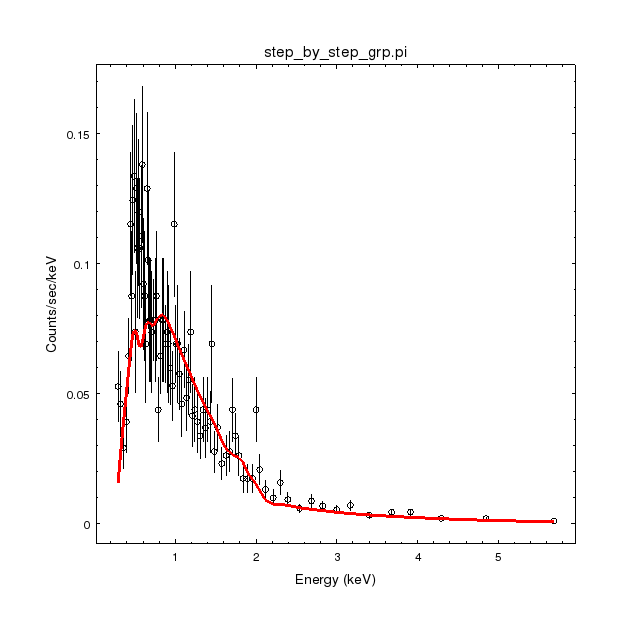

In [28]:
cat << EOM > s1.py
load_data("step_by_step_grp.pi")
notice(0.3,6)
subtract()  
set_source(xsphabs.a1*xspowerlaw.p1)
fit()
plot_fit()
print_window("sherpa_01.png","export.clobber=True")
quit()
EOM

sherpa -n s1.py
display < sherpa_01.png